In [ ]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# ASSUMPTIONS — MODEL B
# ============================================================
# 1. Target: next month's annualized realized volatility (log scale
#    for training, exponentiated back for evaluation).
#
# 2. Regime detection: K-means with k=2 fitted on market-level
#    features (lagged market vol, lagged market return).
#    Fitted on training data only inside each expanding window
#    step — never on future data.
#    Regimes labeled: 0 = low vol, 1 = high vol.
#
# 3. Separate GB model per regime. Each month:
#    - Fit K-means on training months
#    - Assign regimes to train AND test rows
#    - Train one GB per regime on training rows of that regime
#    - Predict for test rows assigned to that regime
#    - Fall back to naive (vol_lag1) if < 50 training rows in regime
#
# 4. Features: lagged vol (1,3,6m), lagged returns, log market cap,
#    liquidity, lagged market vol, lagged market return.
#    All features lagged >= 1 month. No future data.
#
# 5. Expanding window: minimum 60 months (5 years) initial training.
#
# 6. Validation: TimeSeriesSplit, never KFold.
#
# 7. Naive baseline: previous month's realized vol as forecast.
#
# 8. Capital cost: 15% normal months, 30% high vol regime months.
#    Net revenue = gross return - capital_cost_rate * predicted_vol / 12
# ============================================================

print('Imports and assumptions loaded.')

Imports and assumptions loaded.


In [3]:
# ============================================================
# Cell 2 — Load data
# ============================================================
df = pd.read_csv('data/clean_monthly_panel.csv', parse_dates=['date'])
df = df.sort_values(['permno', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Unique stocks: {df["permno"].nunique()}')
print(f'Unique months: {df["date"].nunique()}')

Shape: (1912727, 20)
Columns: ['permno', 'ret', 'real_vol_monthly', 'real_vol_ann', 'real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3', 'mktcap', 'liquidity', 'mkt_vol_ann', 'high_vol_regime', 'n_days', 'date', 'ret_lag1', 'ret_lag3', 'ret_lag6', 'abs_ret_lag1', 'mktcap_lag1', 'momentum_12m', 'mkt_vol_ann_lag1']
Date range: 1990-01-31 00:00:00 to 2023-12-31 00:00:00
Unique stocks: 18074
Unique months: 408


CHECK 1: All required columns present ✅

CHECK 2: Stock count per month
Min: 3265  Max: 7186  Mean: 4688


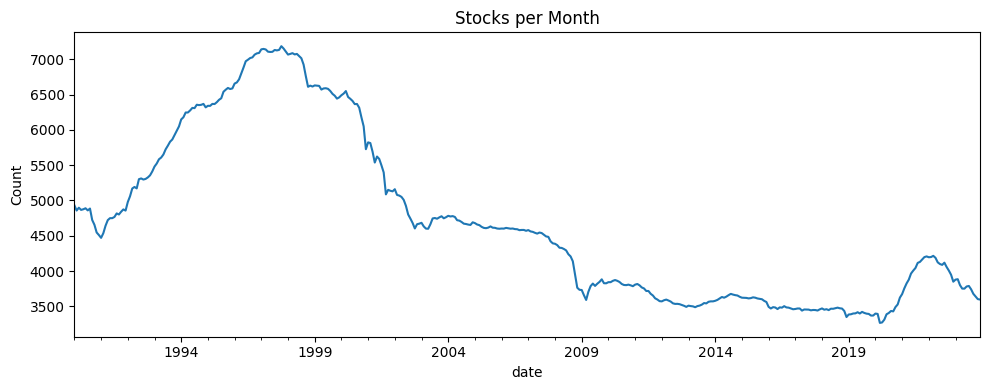


CHECK 3: Crisis months (market vol > 30%): 24


In [4]:
# ============================================================
# Cell 3 — Basic checks
# ============================================================

# CHECK 1: Required columns present
required_cols = ['permno', 'date', 'ret', 'real_vol_monthly',
                 'real_vol_ann', 'mktcap', 'liquidity',
                 'mkt_vol_ann', 'high_vol_regime', 'n_days']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f'WARNING: Missing columns: {missing}')
else:
    print('CHECK 1: All required columns present ✅')

# CHECK 2: Stock count per month
stock_count = df.groupby('date')['permno'].nunique()
print(f'\nCHECK 2: Stock count per month')
print(f'Min: {stock_count.min()}  Max: {stock_count.max()}  Mean: {stock_count.mean():.0f}')
stock_count.plot(figsize=(10, 4), title='Stocks per Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# CHECK 3: Crisis months
crisis_months = df.groupby('date')['high_vol_regime'].first().sum()
print(f'\nCHECK 3: Crisis months (market vol > 30%): {crisis_months}')

In [5]:
# ============================================================
# Cell 4 — Feature engineering
# All features lagged >= 1 month. No future data anywhere.
# ============================================================
df = df.sort_values(['permno', 'date']).reset_index(drop=True)

# Log vol — target is NEXT month's log annualized vol
df['log_vol'] = np.log(df['real_vol_ann'])
df['target_log_vol'] = df.groupby('permno')['log_vol'].shift(-1)

# Vol lags — already computed in notebook 1, just take log versions
df['log_vol_lag1'] = np.log(df['real_vol_ann_lag1'])
df['log_vol_lag3'] = np.log(df['real_vol_ann_lag3'])  # lag3 = 3m avg

# Return features — already in data
# abs_ret_lag1, momentum_12m, ret_lag1, ret_lag3, ret_lag6 already exist

# Size
df['log_mktcap_lag1'] = np.log(df['mktcap_lag1'])

# Liquidity
df['liquidity_lag1'] = df.groupby('permno')['liquidity'].shift(1)

# Market vol lagged — for K-means
df['mkt_vol_lag1'] = df.groupby('permno')['mkt_vol_ann'].shift(1)

# Market return lagged — for K-means
mkt_ret = df.groupby('date')['ret'].mean()
df['mkt_ret'] = df['date'].map(mkt_ret)
df['mkt_ret_lag1'] = df.groupby('permno')['mkt_ret'].shift(1)

features = [
    'log_vol_lag1', 'log_vol_lag3',
    'real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3',
    'abs_ret_lag1', 'ret_lag1', 'ret_lag3', 'ret_lag6', 'momentum_12m',
    'log_mktcap_lag1', 'liquidity_lag1',
    'mkt_vol_lag1', 'mkt_ret_lag1'
]
kmeans_features = ['mkt_vol_lag1', 'mkt_ret_lag1']

print('Feature engineering done ✅')
print(f'Features ({len(features)}): {features}')

# Replace -inf from log(0) with NaN so they get dropped in cell 5
df.replace([np.inf, -np.inf], np.nan, inplace=True)

/Users/meadijkstra/Library/Mobile Documents/com~apple~CloudDocs/Uni/Uni 2025-2026/AI in Finance elective/assignment/ai-finance-project/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/meadijkstra/Library/Mobile Documents/com~apple~CloudDocs/Uni/Uni 2025-2026/AI in Finance elective/assignment/ai-finance-project/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Feature engineering done ✅
Features (14): ['log_vol_lag1', 'log_vol_lag3', 'real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3', 'abs_ret_lag1', 'ret_lag1', 'ret_lag3', 'ret_lag6', 'momentum_12m', 'log_mktcap_lag1', 'liquidity_lag1', 'mkt_vol_lag1', 'mkt_ret_lag1']


In [6]:
# ============================================================
# Cell 5 — Drop NaNs
# NaNs from: rolling warmup (vol_lag6 needs 7m, momentum 13m)
# and last month of each stock (target shift -1)
# ============================================================
model_cols = features + ['target_log_vol', 'permno', 'date', 'real_vol_ann']

df_model = df[model_cols].dropna().copy()
df_model = df_model.sort_values(['date', 'permno']).reset_index(drop=True)

print(f'Rows before dropna: {len(df)}')
print(f'Rows after dropna:  {len(df_model)}')
print(f'Date range: {df_model["date"].min()} to {df_model["date"].max()}')
print(f'Unique stocks: {df_model["permno"].nunique()}')

nan_count = df_model[features + ['target_log_vol']].isna().sum()
total_nans = nan_count.sum()
if total_nans == 0:
    print('NaN check: all zero ✅')
else:
    print(f'WARNING: {total_nans} NaNs remaining:')
    print(nan_count[nan_count > 0])

Rows before dropna: 1912727
Rows after dropna:  1686146
Date range: 1991-01-31 00:00:00 to 2023-11-30 00:00:00
Unique stocks: 16590
NaN check: all zero ✅


In [7]:
# ============================================================
# Cell 6 — Expanding window setup
# ============================================================
all_months = sorted(df_model['date'].unique())
n_months = len(all_months)
min_train_months = 60  # 5 year minimum training window

test_months = all_months[min_train_months:]

print(f'Total months available:      {n_months}')
print(f'Minimum training window:     {min_train_months} months')
print(f'First prediction month:      {test_months[0]}')
print(f'Last prediction month:       {test_months[-1]}')
print(f'Number of prediction months: {len(test_months)}')

Total months available:      395
Minimum training window:     60 months
First prediction month:      1996-01-31 00:00:00
Last prediction month:       2023-11-30 00:00:00
Number of prediction months: 335


In [8]:
# ============================================================
# Cell 7 — Expanding window loop: K-means + GB + Ridge + LASSO
# ============================================================

import warnings
from sklearn.linear_model import RidgeCV, LassoCV
warnings.filterwarnings('ignore', category=UserWarning)

GB_PARAMS = {
    'n_estimators':  50,
    'max_depth':     3,
    'learning_rate': 0.05,
    'subsample':     0.8,
    'random_state':  42
}
LAMBDAS = np.logspace(-4, 4, 20)
K = 2
MIN_REGIME_ROWS = 50
MAX_TRAIN_ROWS  = 20000

results = []

for i, test_month in enumerate(test_months):

    train_mask = df_model['date'] < test_month
    test_mask  = df_model['date'] == test_month

    df_train = df_model[train_mask].copy()
    df_test  = df_model[test_mask].copy()

    if len(df_test) == 0:
        continue

    # K-means on one row per month (market level)
    mkt_train = (df_train.groupby('date')[kmeans_features]
                 .first().reset_index(drop=True))

    scaler_km = StandardScaler()
    mkt_train_sc = scaler_km.fit_transform(mkt_train)

    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(mkt_train_sc)

    high_vol_cluster = int(np.argmax(km.cluster_centers_[:, 0]))

    df_train['regime'] = (km.predict(scaler_km.transform(
        df_train[kmeans_features].values)) == high_vol_cluster).astype(int)
    df_test['regime'] = (km.predict(scaler_km.transform(
        df_test[kmeans_features].values)) == high_vol_cluster).astype(int)

    # Initialise prediction columns
    df_test['pred_log_vol_gb']    = np.nan
    df_test['pred_log_vol_ridge'] = np.nan
    df_test['pred_log_vol_lasso'] = np.nan
    df_test['pred_log_vol_naive'] = df_test['log_vol_lag1'].values
    df_test['fallback_used']      = False

    for regime in [0, 1]:
        train_r = df_train[df_train['regime'] == regime]
        test_r  = df_test[df_test['regime'] == regime]

        if len(test_r) == 0:
            continue

        if len(train_r) < MIN_REGIME_ROWS:
            for col in ['pred_log_vol_gb', 'pred_log_vol_ridge', 'pred_log_vol_lasso']:
                df_test.loc[df_test['regime'] == regime, col] = \
                    df_test.loc[df_test['regime'] == regime, 'log_vol_lag1']
            df_test.loc[df_test['regime'] == regime, 'fallback_used'] = True
            continue

        if len(train_r) > MAX_TRAIN_ROWS:
            train_r = train_r.sample(MAX_TRAIN_ROWS, random_state=42)

        X_train_r = train_r[features].values
        y_train_r = train_r['target_log_vol'].values
        X_test_r  = test_r[features].values

        scaler_r = StandardScaler()
        X_train_r_sc = scaler_r.fit_transform(X_train_r)
        X_test_r_sc  = scaler_r.transform(X_test_r)

        # Gradient Boosting
        gb = GradientBoostingRegressor(**GB_PARAMS)
        gb.fit(X_train_r_sc, y_train_r)
        df_test.loc[df_test['regime'] == regime, 'pred_log_vol_gb'] = \
            gb.predict(X_test_r_sc)

        # Ridge
        tscv = TimeSeriesSplit(n_splits=5)
        ridge = RidgeCV(alphas=LAMBDAS, cv=tscv)
        ridge.fit(X_train_r_sc, y_train_r)
        df_test.loc[df_test['regime'] == regime, 'pred_log_vol_ridge'] = \
            ridge.predict(X_test_r_sc)

        # LASSO
        lasso = LassoCV(alphas=LAMBDAS, cv=tscv, max_iter=5000)
        lasso.fit(X_train_r_sc, y_train_r)
        df_test.loc[df_test['regime'] == regime, 'pred_log_vol_lasso'] = \
            lasso.predict(X_test_r_sc)

    results.append(df_test[['permno', 'date', 'target_log_vol',
                             'real_vol_ann', 'regime',
                             'pred_log_vol_gb', 'pred_log_vol_ridge',
                             'pred_log_vol_lasso', 'pred_log_vol_naive',
                             'fallback_used']])

    if (i + 1) % 12 == 0:
        print(f'Completed {i+1}/{len(test_months)} months '
              f'— last: {test_month.date()}')

df_results = pd.concat(results, ignore_index=True)

print(f'\nResults shape: {df_results.shape}')
print(f'Months covered: {df_results["date"].nunique()}')
print(f'Fallback rows used: {df_results["fallback_used"].sum()}')
print(df_results.head())

Completed 12/335 months — last: 1996-12-31
Completed 24/335 months — last: 1997-12-31
Completed 36/335 months — last: 1998-12-31
Completed 48/335 months — last: 1999-12-31
Completed 60/335 months — last: 2000-12-31
Completed 72/335 months — last: 2001-12-31
Completed 84/335 months — last: 2002-12-31
Completed 96/335 months — last: 2003-12-31
Completed 108/335 months — last: 2004-12-31
Completed 120/335 months — last: 2005-12-31
Completed 132/335 months — last: 2006-12-31
Completed 144/335 months — last: 2007-12-31
Completed 156/335 months — last: 2008-12-31
Completed 168/335 months — last: 2009-12-31
Completed 180/335 months — last: 2010-12-31
Completed 192/335 months — last: 2011-12-31
Completed 204/335 months — last: 2012-12-31
Completed 216/335 months — last: 2013-12-31
Completed 228/335 months — last: 2014-12-31
Completed 240/335 months — last: 2015-12-31
Completed 252/335 months — last: 2016-12-31
Completed 264/335 months — last: 2017-12-31
Completed 276/335 months — last: 2018-12

In [9]:
# Clip extreme log predictions before back-transforming
for col in ['pred_log_vol_gb', 'pred_log_vol_ridge', 'pred_log_vol_lasso', 'pred_log_vol_naive']:
    df_results[col] = df_results[col].clip(-5, 2)


df_results['pred_vol_gb']    = np.exp(df_results['pred_log_vol_gb'])
df_results['pred_vol_ridge'] = np.exp(df_results['pred_log_vol_ridge'])
df_results['pred_vol_lasso'] = np.exp(df_results['pred_log_vol_lasso'])
df_results['pred_vol_naive'] = np.exp(df_results['pred_log_vol_naive'])
df_results['actual_vol']     = df_results['real_vol_ann']

def eval_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    print(f'{name:25s} | RMSE: {rmse:.4f} | R2: {r2:.4f}')

print('=== Overall Performance (vol scale) ===')
eval_model(df_results['actual_vol'], df_results['pred_vol_gb'],    'GB (K-means)')
eval_model(df_results['actual_vol'], df_results['pred_vol_ridge'], 'Ridge (K-means)')
eval_model(df_results['actual_vol'], df_results['pred_vol_lasso'], 'LASSO (K-means)')
eval_model(df_results['actual_vol'], df_results['pred_vol_naive'], 'Naive baseline')
print()

print('=== Performance by Regime ===')
for regime, label in [(0, 'Low vol regime'), (1, 'High vol regime')]:
    sub = df_results[df_results['regime'] == regime]
    if len(sub) == 0:
        continue
    print(f'\n  {label} (n={len(sub)})')
    eval_model(sub['actual_vol'], sub['pred_vol_gb'],    '  GB')
    eval_model(sub['actual_vol'], sub['pred_vol_ridge'], '  Ridge')
    eval_model(sub['actual_vol'], sub['pred_vol_lasso'], '  LASSO')
    eval_model(sub['actual_vol'], sub['pred_vol_naive'], '  Naive')

r2_gb    = r2_score(df_results['actual_vol'], df_results['pred_vol_gb'])
r2_naive = r2_score(df_results['actual_vol'], df_results['pred_vol_naive'])

print('\n=== PASS/FAIL ===')
print(f'GB R2 positive:     {"PASS ✅" if r2_gb > 0 else "FAIL ❌"}')
print(f'GB beats naive R2:  {"PASS ✅" if r2_gb > r2_naive else "WARN ⚠️"}')

=== Overall Performance (vol scale) ===
GB (K-means)              | RMSE: 0.0556 | R2: 0.4860
Ridge (K-means)           | RMSE: 0.0641 | R2: 0.3170
LASSO (K-means)           | RMSE: 0.0638 | R2: 0.3225
Naive baseline            | RMSE: 0.0684 | R2: 0.2222

=== Performance by Regime ===

  Low vol regime (n=922255)
  GB                      | RMSE: 0.0489 | R2: 0.4960
  Ridge                   | RMSE: 0.0601 | R2: 0.2383
  LASSO                   | RMSE: 0.0599 | R2: 0.2434
  Naive                   | RMSE: 0.0639 | R2: 0.1394

  High vol regime (n=467531)
  GB                      | RMSE: 0.0669 | R2: 0.4327
  Ridge                   | RMSE: 0.0713 | R2: 0.3553
  LASSO                   | RMSE: 0.0709 | R2: 0.3618
  Naive                   | RMSE: 0.0765 | R2: 0.2577

=== PASS/FAIL ===
GB R2 positive:     PASS ✅
GB beats naive R2:  PASS ✅


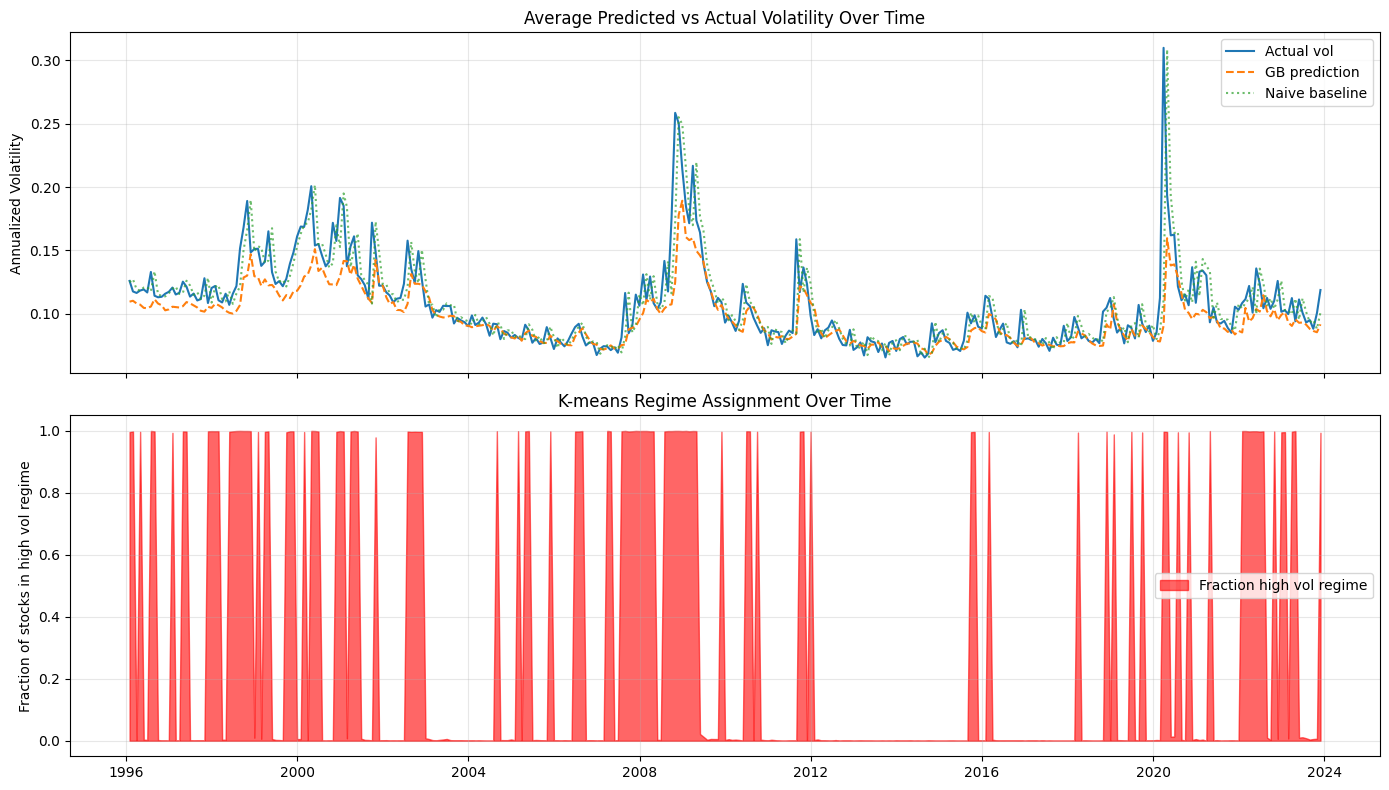

Saved to data/model_a_vol_plot.png
GB predictions should spike around 2001, 2008, 2020.
High vol regime fraction should align with those crises.


In [10]:
# ============================================================
# Cell 9 — Visualise: predicted vs actual vol + regime over time
# ============================================================
monthly_avg = df_results.groupby('date').agg(
    actual_vol     = ('actual_vol',     'mean'),
    pred_vol_gb    = ('pred_vol_gb',    'mean'),
    pred_vol_naive = ('pred_vol_naive', 'mean'),
    pct_high_vol   = ('regime',         'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_avg['date'], monthly_avg['actual_vol'],
             label='Actual vol', linewidth=1.5)
axes[0].plot(monthly_avg['date'], monthly_avg['pred_vol_gb'],
             label='GB prediction', linestyle='--')
axes[0].plot(monthly_avg['date'], monthly_avg['pred_vol_naive'],
             label='Naive baseline', linestyle=':', alpha=0.7)
axes[0].set_ylabel('Annualized Volatility')
axes[0].set_title('Average Predicted vs Actual Volatility Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(monthly_avg['date'], monthly_avg['pct_high_vol'],
                     alpha=0.6, color='red', label='Fraction high vol regime')
axes[1].set_ylabel('Fraction of stocks in high vol regime')
axes[1].set_title('K-means Regime Assignment Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/model_a_vol_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/model_a_vol_plot.png')
print('GB predictions should spike around 2001, 2008, 2020.')
print('High vol regime fraction should align with those crises.')

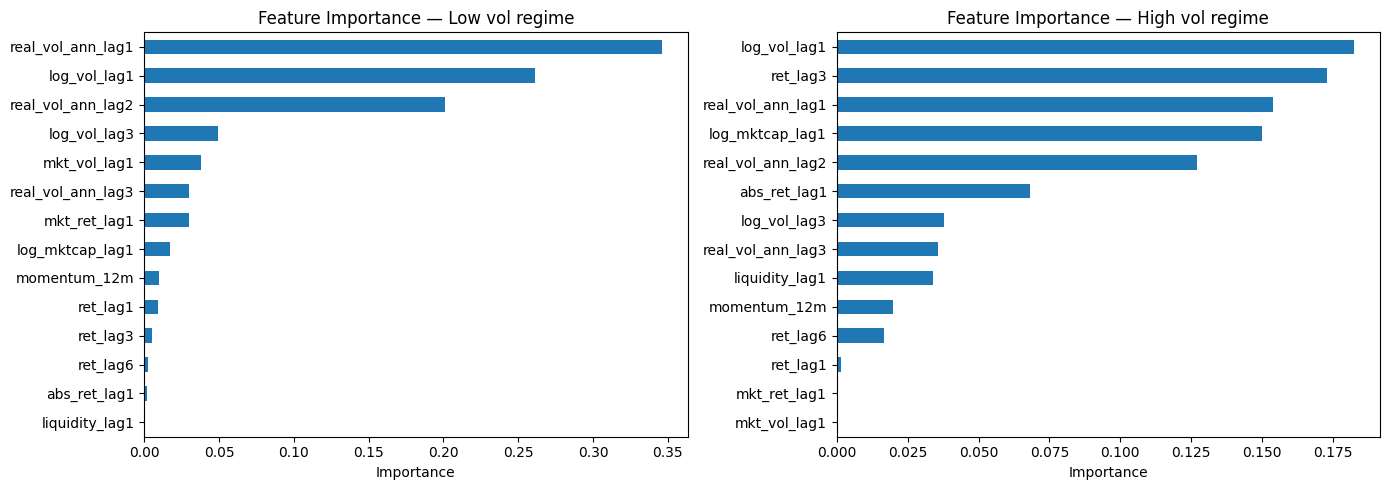

Saved to data/model_a_feature_importance.png


In [11]:
# ============================================================
# Cell 10 — Feature importance (last 60-month window)
# For interpretation only — not used for predictions.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

last_date    = df_model['date'].max()
window_start = all_months[-61]
window_data  = df_model[
    (df_model['date'] >= window_start) &
    (df_model['date'] < last_date)
].copy()

mkt_window = (window_data.groupby('date')[kmeans_features]
              .first().reset_index(drop=True))
scaler_fi = StandardScaler()
mkt_sc = scaler_fi.fit_transform(mkt_window)
km_fi = KMeans(n_clusters=2, random_state=42, n_init=10)
km_fi.fit(mkt_sc)
high_cluster = int(np.argmax(km_fi.cluster_centers_[:, 0]))
row_sc = scaler_fi.transform(window_data[kmeans_features].values)
window_data['regime'] = (km_fi.predict(row_sc) == high_cluster).astype(int)

for regime, label, ax in [(0, 'Low vol regime', axes[0]),
                           (1, 'High vol regime', axes[1])]:
    sub = window_data[window_data['regime'] == regime]
    if len(sub) < MIN_REGIME_ROWS:
        ax.set_title(f'{label} — not enough data')
        continue

    scaler_fi2 = StandardScaler()
    X = scaler_fi2.fit_transform(sub[features].values)
    y = sub['target_log_vol'].values

    gb_fi = GradientBoostingRegressor(**GB_PARAMS)
    gb_fi.fit(X, y)

    importances = pd.Series(gb_fi.feature_importances_, index=features)
    importances.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance — {label}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('data/model_a_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/model_a_feature_importance.png')

In [12]:
# ============================================================
# Cell 11 — Save predictions 
# ============================================================
df_results.to_csv('data/model_a_predictions.csv', index=False)

print('=== DONE ===')
print('Saved to data/model_a_predictions.csv')
print()
print('Columns available for backtesting:')
print(df_results.columns.tolist())
print()
print('  pred_vol_gb    — Model A vol forecast (use for capital cost)')
print('  pred_vol_naive — naive baseline forecast')
print('  actual_vol     — realised vol (for evaluation)')
print('  regime         — 0=low vol, 1=high vol')

=== DONE ===
Saved to data/model_a_predictions.csv

Columns available for backtesting:
['permno', 'date', 'target_log_vol', 'real_vol_ann', 'regime', 'pred_log_vol_gb', 'pred_log_vol_ridge', 'pred_log_vol_lasso', 'pred_log_vol_naive', 'fallback_used', 'pred_vol_gb', 'pred_vol_ridge', 'pred_vol_lasso', 'pred_vol_naive', 'actual_vol']

  pred_vol_gb    — Model A vol forecast (use for capital cost)
  pred_vol_naive — naive baseline forecast
  actual_vol     — realised vol (for evaluation)
  regime         — 0=low vol, 1=high vol


In [16]:
# ============================================================
# Cell 12 — Backtest + Save for Model Comparison
# ============================================================
from pathlib import Path

# Load actual returns (needed for real net revenue)
data_path = Path('data')
panel = pd.read_csv(data_path / 'clean_monthly_panel.csv', parse_dates=['date'])
panel = panel[['permno', 'date', 'ret', 'high_vol_regime', 'mkt_vol_ann', 'real_vol_ann_lag1']]
# Merge predictions with actual returns
backtest_df = df_results.merge(panel, on=['permno', 'date'], how='left')

# ── Monthly backtest loop ───────────────────────────────────
N_STOCKS = 500

model_a_results = []

for date, month_df in backtest_df.groupby('date'):
    month_df = month_df.dropna(subset=['pred_vol_gb', 'ret']).copy()

    if len(month_df) < N_STOCKS:
        continue

    high_vol_regime = month_df['high_vol_regime'].iloc[0]
    cost_rate = 0.30 if high_vol_regime else 0.15

    # Select 500 stocks with lowest predicted vol
    # Selection based only on info available at start of month
    selected = month_df.nsmallest(N_STOCKS, 'pred_vol_gb')

    # Actual net revenue using real returns
    avg_net_rev = (
    selected['ret'] - cost_rate * selected['real_vol_ann_lag1'] / 12
    ).mean()

    model_a_results.append({
        'date'           : date,
        'avg_net_revenue': avg_net_rev,
        'high_vol_regime': high_vol_regime,
        'mkt_vol_ann'    : month_df['mkt_vol_ann'].iloc[0],
        'invested'       : True
    })

model_a_monthly = pd.DataFrame(model_a_results).sort_values('date').reset_index(drop=True)
model_a_monthly['cumulative_net_revenue'] = (
    (1 + model_a_monthly['avg_net_revenue']).cumprod()
)

print(f'Months covered: {len(model_a_monthly)}')
print(f'Avg monthly net revenue: {model_a_monthly["avg_net_revenue"].mean():.4%}')
print(f'Avg annual net revenue:  {model_a_monthly["avg_net_revenue"].mean()*12:.4%}')

# ── Save for group comparison ───────────────────────────────
import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import summarise_portfolio

summarise_portfolio(model_a_monthly, label='model_a')

Months covered: 335
Avg monthly net revenue: 0.9619%
Avg annual net revenue:  11.5430%
  MODEL_A — SUMMARY STATISTICS
Months:                    335
Avg monthly net revenue:   0.9619%
Avg annual net revenue:    11.5430%
Std monthly net revenue:   3.1533%
Sharpe ratio (annualized): 1.0567
Best month:  2020-11 (10.1636%)
Worst month: 2020-03 (-15.6639%)

--- CRISIS VS NORMAL ---
Normal months (311):  avg 1.1191%/month
Crisis months ( 24):  avg -1.0752%/month

--- OOS PERIOD (2010–2023) ---
Months:                    167
Avg annual net revenue:    12.3472%
Sharpe ratio (annualized): 1.0713

Saved to data/summary_model_a.json ✅
Saved to data/monthly_results_model_a.csv ✅


{'label': 'model_a',
 'full_period_annual_net_revenue': np.float64(0.11542994089182282),
 'full_period_sharpe': np.float64(1.0567370452821103),
 'full_period_worst_month': np.float64(-0.15663851864118777),
 'full_period_best_month': np.float64(0.1016361817111837),
 'crisis_avg_monthly': np.float64(-0.010752284369771756),
 'normal_avg_monthly': np.float64(0.011191234752747832),
 'oos_annual_net_revenue': np.float64(0.12347164122558646),
 'oos_sharpe': np.float64(1.071256178871123)}